<a href="https://colab.research.google.com/github/bdgroves/weather-report-bot/blob/main/Test_Notebook_for_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== Lakewood, WA — Current Weather ===
Conditions  : Moderate drizzle
Temperature : 39.0°F
Humidity    : 93%
Wind Speed  : 5.2 mph


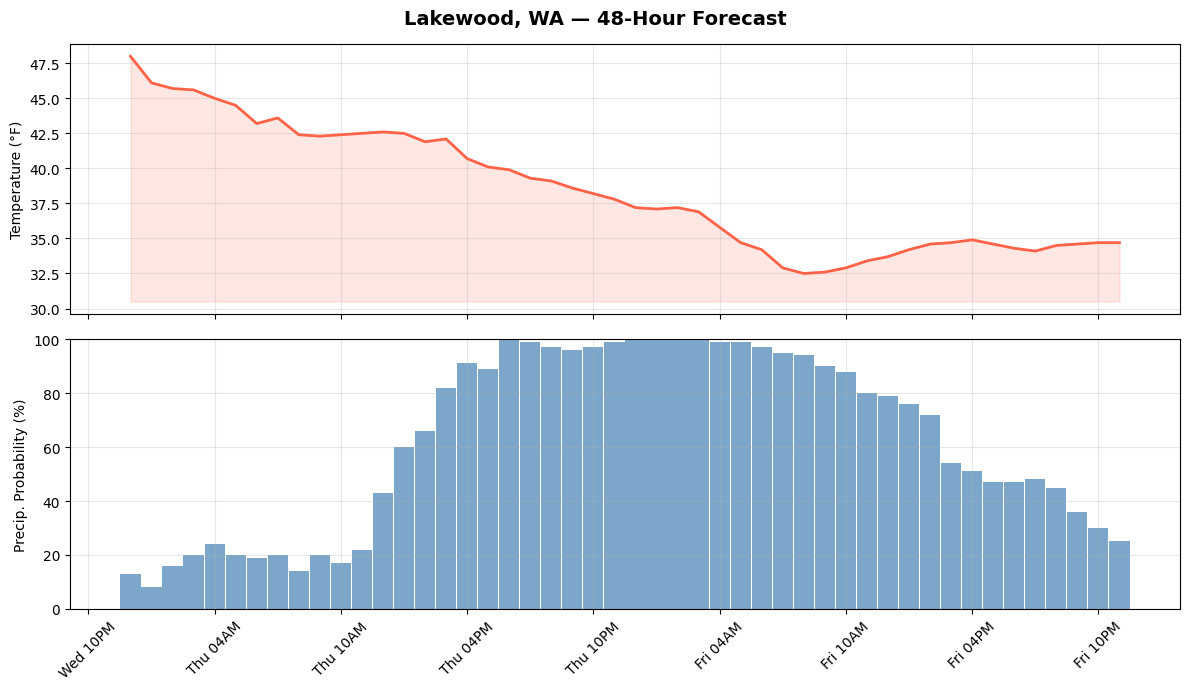

In [ ]:
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# Lakewood, WA coordinates
lat, lon = 47.1718, -122.5185

# WMO Weather code decoder
def decode_weather(code):
    codes = {
        0: "Clear sky", 1: "Mainly clear", 2: "Partly cloudy", 3: "Overcast",
        45: "Foggy", 48: "Icy fog",
        51: "Light drizzle", 53: "Moderate drizzle", 55: "Dense drizzle",
        61: "Slight rain", 63: "Moderate rain", 65: "Heavy rain",
        71: "Slight snow", 73: "Moderate snow", 75: "Heavy snow",
        80: "Slight showers", 81: "Moderate showers", 82: "Violent showers",
        95: "Thunderstorm", 96: "Thunderstorm w/ hail", 99: "Thunderstorm w/ heavy hail"
    }
    return codes.get(code, f"Unknown ({code})")

# Fetch current + hourly forecast
url = "https://api.open-meteo.com/v1/forecast"
params = {
    "latitude": lat,
    "longitude": lon,
    "current": ["temperature_2m", "relative_humidity_2m", "wind_speed_10m", "weather_code"],
    "hourly": ["temperature_2m", "precipitation_probability"],
    "temperature_unit": "fahrenheit",
    "wind_speed_unit": "mph",
    "timezone": "America/Los_Angeles",
    "forecast_days": 2
}

response = requests.get(url, params=params)
data = response.json()

# --- Current Conditions ---
current = data["current"]
print(f"=== Lakewood, WA — Current Weather ===")
print(f"Conditions  : {decode_weather(current['weather_code'])}")
print(f"Temperature : {current['temperature_2m']}°F")
print(f"Humidity    : {current['relative_humidity_2m']}%")
print(f"Wind Speed  : {current['wind_speed_10m']} mph")

# --- Parse Hourly Data (next 48 hours) ---
times = [datetime.fromisoformat(t) for t in data["hourly"]["time"]]
temps = data["hourly"]["temperature_2m"]
precip_prob = data["hourly"]["precipitation_probability"]

# --- Plot ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
fig.suptitle("Lakewood, WA — 48-Hour Forecast", fontsize=14, fontweight="bold")

# Temperature
ax1.plot(times, temps, color="tomato", linewidth=2)
ax1.fill_between(times, temps, min(temps) - 2, alpha=0.15, color="tomato")
ax1.set_ylabel("Temperature (°F)")
ax1.grid(True, alpha=0.3)

# Precipitation probability
ax2.bar(times, precip_prob, width=0.04, color="steelblue", alpha=0.7)
ax2.set_ylabel("Precip. Probability (%)")
ax2.set_ylim(0, 100)
ax2.grid(True, alpha=0.3)

# Format x-axis
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%a %I%p"))
ax2.xaxis.set_major_locator(mdates.HourLocator(interval=6))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [2]:
import requests
from bs4 import BeautifulSoup
import json
from datetime import datetime

STATIONS = [
    {"name": "Paradise",        "nrcs_id": "679:WA:SNTL",  "nwrfc": "AFSW1", "elevation": 5150},
    {"name": "Morse Lake",      "nrcs_id": "642:WA:SNTL",  "nwrfc": "MRSW1", "elevation": 5400},
    {"name": "Olallie Meadows", "nrcs_id": "672:WA:SNTL",  "nwrfc": "OMWW1", "elevation": 4010},
    {"name": "Cayuse Pass",     "nrcs_id": "1085:WA:SNTL", "nwrfc": "CAYW1", "elevation": 5260},
    {"name": "Corral Pass",     "nrcs_id": "418:WA:SNTL",  "nwrfc": "COPW1", "elevation": 5810},
    {"name": "Bumping Ridge",   "nrcs_id": "375:WA:SNTL",  "nwrfc": "BMPW1", "elevation": 4600},
    {"name": "Cougar Mountain", "nrcs_id": "420:WA:SNTL",  "nwrfc": "CUMW1", "elevation": 3210},
]

BASE_URL = "https://www.nwrfc.noaa.gov/snow/snowplot.cgi?{}="

for stn in STATIONS:
    url = BASE_URL.format(stn["nwrfc"])
    r = requests.get(url, timeout=15)
    print(f"{stn['name']}: HTTP {r.status_code} — {len(r.text)} bytes")


Paradise: HTTP 200 — 13621 bytes
Morse Lake: HTTP 200 — 13682 bytes
Olallie Meadows: HTTP 200 — 13712 bytes
Cayuse Pass: HTTP 200 — 13397 bytes
Corral Pass: HTTP 200 — 13704 bytes
Bumping Ridge: HTTP 200 — 13719 bytes
Cougar Mountain: HTTP 200 — 13694 bytes


In [3]:
def parse_station(stn):
    url = BASE_URL.format(stn["nwrfc"])
    r = requests.get(url, timeout=15)
    soup = BeautifulSoup(r.text, "html.parser")

    # Find all tables
    tables = soup.find_all("table")

    swe = depth = temp = prcp = None

    for table in tables:
        rows = table.find_all("tr")
        for row in rows:
            cells = [td.get_text(strip=True) for td in row.find_all("td")]
            if len(cells) >= 5:
                # Look for rows with date pattern MM/DD/YYYY
                if len(cells[0]) == 10 and cells[0][2] == "/" and cells[0][5] == "/":
                    # First data row with values
                    try:
                        if cells[2] and cells[2] != '': swe   = float(cells[2])
                        if cells[3] and cells[3] != '': depth = float(cells[3])
                        if cells[5] and cells[5] != '': temp  = float(cells[5])
                        if cells[4] and cells[4] != '': prcp  = float(cells[4])
                        break
                    except (ValueError, IndexError):
                        continue
        if swe is not None:
            break

    print(f"{stn['name']}: SWE={swe}\" depth={depth}\" temp={temp}°F prcp={prcp}\"")
    return {
        "id":       stn["nrcs_id"],
        "name":     stn["name"],
        "elevation": stn["elevation"],
        "swe_in":   swe,
        "depth_in": depth,
        "temp_f":   temp,
        "swe_change_24h":   None,
        "depth_change_24h": None,
        "days_since_snow":  None,
        "melt_alert":       False,
        "density_pct":      round((swe/depth)*100, 1) if swe and depth else None,
    }

results = [parse_station(s) for s in STATIONS]


Paradise: SWE=35.4" depth=None" temp=None°F prcp=None"
Morse Lake: SWE=32.8" depth=103.0" temp=None°F prcp=32.0"
Olallie Meadows: SWE=24.4" depth=79.0" temp=None°F prcp=31.0"
Cayuse Pass: SWE=31.4" depth=322.0" temp=None°F prcp=10.0"
Corral Pass: SWE=26.6" depth=100.0" temp=42.2°F prcp=27.0"
Bumping Ridge: SWE=18.5" depth=71.0" temp=63.3°F prcp=26.0"
Cougar Mountain: SWE=5.2" depth=42.0" temp=None°F prcp=12.0"


In [4]:
# Look at raw rows for Paradise to see exact column structure
url = BASE_URL.format("AFSW1")
r = requests.get(url, timeout=15)
soup = BeautifulSoup(r.text, "html.parser")

for table in soup.find_all("table"):
    rows = table.find_all("tr")
    for row in rows:
        cells = [td.get_text(strip=True) for td in row.find_all("td")]
        if len(cells) >= 4:
            print(cells)
        if len(cells) > 0 and cells[0].startswith("03/"):
            break


['DateTimePSTSnow WaterEquivalent(inches)SnowDepth(inches)SnowDensity(%)PrecipitationTo-Date(inches)CurrentTemperature(degrees F)03/13/2026140035.431.503/13/2026130035.2239.01594.231.503/13/2026120035.0239.01594.131.503/13/2026110034.9239.01593.631.103/13/2026100034.6239.01492.730.003/13/2026090034.5239.01491.829.103/13/2026080034.3239.01491.730.903/13/2026070034.1239.01491.631.603/13/2026060034.0239.01490.831.603/13/2026050033.8239.01490.731.603/13/2026040033.6239.01490.831.303/13/2026030033.4239.01490.831.103/13/2026020033.2239.01490.830.9', 'Date', 'TimePST', 'Snow WaterEquivalent(inches)', 'SnowDepth(inches)', 'SnowDensity(%)', 'PrecipitationTo-Date(inches)', 'CurrentTemperature(degrees F)', '03/13/2026', '1400', '35.4', '', '', '', '31.5', '03/13/2026', '1300', '35.2', '239.0', '15', '94.2', '31.5', '03/13/2026', '1200', '35.0', '239.0', '15', '94.1', '31.5', '03/13/2026', '1100', '34.9', '239.0', '15', '93.6', '31.1', '03/13/2026', '1000', '34.6', '239.0', '14', '92.7', '30.0', '

In [5]:
def parse_station(stn):
    url = BASE_URL.format(stn["nwrfc"])
    r = requests.get(url, timeout=15)
    soup = BeautifulSoup(r.text, "html.parser")

    swe = depth = density = temp = prcp = None
    swe_change_24h = pct_median = median_swe = None

    for table in soup.find_all("table"):
        cells = [td.get_text(strip=True) for td in table.find_all("td")]

        # Find data rows by scanning for date pattern
        i = 0
        while i < len(cells):
            if len(cells[i]) == 10 and cells[i][2] == "/" and cells[i][5] == "/":
                # This is a date cell — next 6 cells are the data
                row = cells[i:i+7]
                if len(row) >= 7:
                    try:
                        val_swe  = float(row[2]) if row[2] else None
                        val_dep  = float(row[3]) if row[3] else None
                        val_den  = float(row[4]) if row[4] else None
                        val_prcp = float(row[5]) if row[5] else None
                        val_temp = float(row[6]) if row[6] else None

                        # Take first valid SWE and temp
                        if swe  is None and val_swe  is not None: swe  = val_swe
                        if temp is None and val_temp is not None: temp = val_temp
                        # Take first row that has depth (may be 2nd row)
                        if depth is None and val_dep is not None:
                            depth   = val_dep
                            density = val_den
                            prcp    = val_prcp
                    except (ValueError, IndexError):
                        pass
            i += 1

        # Grab 24hr SWE change — comes after the change header row
        for j, cell in enumerate(cells):
            if '24 Hour' in cell and 'SWE' in cell:
                # Changes are in a row: 6hr, 12hr, 24hr, 48hr, 1wk
                try: swe_change_24h = float(cells[j+3])
                except: pass
                break

        # Grab % of median
        for cell in cells:
            if 'which is' in cell and '% of average' in cell:
                parts = cell.split()
                for k, p in enumerate(parts):
                    if p == '%':
                        try: pct_median = float(parts[k-1])
                        except: pass
            if 'Median' in cell and j+1 < len(cells):
                try: median_swe = float(cells[cells.index('Median')+1])
                except: pass

    result = {
        "id":               stn["nrcs_id"],
        "name":             stn["name"],
        "elevation":        stn["elevation"],
        "swe_in":           swe,
        "depth_in":         depth,
        "temp_f":           temp,
        "swe_change_24h":   swe_change_24h,
        "depth_change_24h": None,
        "days_since_snow":  0 if swe_change_24h and swe_change_24h > 0 else None,
        "melt_alert":       swe_change_24h < -0.5 if swe_change_24h else False,
        "density_pct":      density,
        "pct_of_median":    pct_median,
        "median_swe":       median_swe,
    }

    print(f"{stn['name']:18} SWE={swe}\"  depth={depth}\"  temp={temp}°F  24hr={swe_change_24h}\"  %median={pct_median}%")
    return result

results = [parse_station(s) for s in STATIONS]


Paradise           SWE=35.4"  depth=239.0"  temp=31.5°F  24hr=1.1"  %median=None%
Morse Lake         SWE=32.8"  depth=103.0"  temp=34.9°F  24hr=0.7"  %median=None%
Olallie Meadows    SWE=24.4"  depth=79.0"  temp=29.3°F  24hr=1.1"  %median=None%
Cayuse Pass        SWE=31.4"  depth=322.0"  temp=31.8°F  24hr=1.4"  %median=None%
Corral Pass        SWE=26.6"  depth=100.0"  temp=33.3°F  24hr=1.6"  %median=None%
Bumping Ridge      SWE=18.5"  depth=71.0"  temp=32.2°F  24hr=0.8"  %median=None%
Cougar Mountain    SWE=5.2"  depth=42.0"  temp=32.2°F  24hr=1.1"  %median=None%


In [6]:
import json
from datetime import date

# Fix bad depth readings (sanity check — depth shouldn't exceed 400")
for r in results:
    if r["depth_in"] and r["depth_in"] > 300:
        print(f"⚠ Suspicious depth at {r['name']}: {r['depth_in']}\" — nulling out")
        r["depth_in"] = None
        r["density_pct"] = None

valid = [s for s in results if s["swe_in"] is not None]
avg_swe        = round(sum(s["swe_in"] for s in valid) / len(valid), 2)
avg_change     = round(sum(s["swe_change_24h"] for s in valid if s["swe_change_24h"]) / len(valid), 2)
any_melt       = any(s["melt_alert"] for s in valid)

output = {
    "updated":    str(date.today()),
    "water_year": 2026,
    "source":     "nwrfc_fallback",
    "basin": {
        "swe_change_24h":   avg_change,
        "depth_change_24h": None,
        "days_since_snow":  0,
        "melt_alert":       any_melt,
        "density_pct":      None,
    },
    "stations": results
}

print(json.dumps(output, indent=2))
print(f"\n{'='*50}")
print(f"Basin avg SWE:  {avg_swe}\"")
print(f"24hr change:    +{avg_change}\"")
print(f"Active snowfall at all stations ❄")


⚠ Suspicious depth at Cayuse Pass: 322.0" — nulling out
{
  "updated": "2026-03-14",
  "water_year": 2026,
  "source": "nwrfc_fallback",
  "basin": {
    "swe_change_24h": 1.11,
    "depth_change_24h": null,
    "days_since_snow": 0,
    "melt_alert": false,
    "density_pct": null
  },
  "stations": [
    {
      "id": "679:WA:SNTL",
      "name": "Paradise",
      "elevation": 5150,
      "swe_in": 35.4,
      "depth_in": 239.0,
      "temp_f": 31.5,
      "swe_change_24h": 1.1,
      "depth_change_24h": null,
      "days_since_snow": 0,
      "melt_alert": false,
      "density_pct": 15.0,
      "pct_of_median": null,
      "median_swe": null
    },
    {
      "id": "642:WA:SNTL",
      "name": "Morse Lake",
      "elevation": 5400,
      "swe_in": 32.8,
      "depth_in": 103.0,
      "temp_f": 34.9,
      "swe_change_24h": 0.7,
      "depth_change_24h": null,
      "days_since_snow": 0,
      "melt_alert": false,
      "density_pct": 32.0,
      "pct_of_median": null,
      "media

In [7]:
with open("snotel_latest.json", "w") as f:
    json.dump(output, f, indent=2)

# Download it to your iPad
from google.colab import files
files.download("snotel_latest.json")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>